The MIT License (MIT)

Copyright © 2026 Martin Ladecký, Jan Papež, Petr Tichý, Lars Pastewka

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

# Iterative error estimates in PCG — Problem P1: square inclusion
Supplementary notebook to M. Ladecký, J. Papež, P. Tichý, L. Pastewka, *Guaranteed Bounds on the Iterative Error of CG-Accelerated FFT-Based Homogenization*, Section 6 (problem P1, Figure 1(a)).

The PCG with the error bounds and estimates (Algorithm 1 of the paper) is in `pcg_error_estimates.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pcg_error_estimates import pcg
%matplotlib inline

# Plot styles of the paper: one colour, line style and marker per quantity;
# markers: v = upper bound or estimate, ^ = lower bound
STYLE = {
    "error":   dict(color='black',      ls='-',  marker=None, lw=1.2),
    "rr":      dict(color='tab:blue',   ls='-',  marker=None, lw=0.9),
    "triv_UB": dict(color='tab:purple', ls='-.', marker='v',  lw=0.9),
    "triv_LB": dict(color='tab:purple', ls='-.', marker='^',  lw=0.9),
    "GR":      dict(color='tab:green',  ls='--', marker='v',  lw=0.9),
    "PT_LB":   dict(color='tab:red',    ls='--', marker='^',  lw=0.9),
    "PT_UE":   dict(color='tab:red',    ls=':',  marker='v',  lw=0.9),
}

# end of the x-axis in the paper's figures: last k at which y is still above floor, plus one
def last_iteration(y, floor):
    above = np.flatnonzero(np.abs(np.asarray(y)) >= floor)
    return int(above[-1]) + 1 if above.size else len(y) - 1

## Element Library Functions

In [2]:
def get_shape_function_gradients(discretization_type, pixel_size):
    if discretization_type == 'linear_triangles':
        # 1 ─── 3          Triangle 0: nodes (0, 1, 2)  - lower left
        # │ \   │          Triangle 1: nodes (1, 2, 3)  - upper right
        # │   \ │
        # 0 ─── 2
        ndim, nb_quad = 2, 2
        dx, dy = pixel_size
        B = np.zeros([ndim, nb_quad, 4])
        B[:, 0, :] = [[-1 / dx, 0, 1 / dx, 0],
                      [-1 / dy, 1 / dy, 0, 0]]
        B[:, 1, :] = [[0, -1 / dx, 0, 1 / dx],
                      [0, 0, -1 / dy, 1 / dy]]

        weights = np.array([dx * dy / 2, dx * dy / 2])
        return B.reshape(ndim, nb_quad, 2, 2), weights, nb_quad

def get_gradient_operators(discretization_type, pixel_size, N, n_dofs):
    ndim = 2
    B_dqij, weights, nb_quad = get_shape_function_gradients(discretization_type, pixel_size)

    def B(u):
        grad = np.zeros([n_dofs, ndim, nb_quad, *N])
        for node in np.ndindex(2, 2):
            node = np.array(node)
            grad += np.einsum('jq,ixy->ijqxy', B_dqij[..., node[0], node[1]],
                              np.roll(u, -node, axis=(1,2)))
        return grad

    def Bw_t(flux):
        div = np.zeros([n_dofs, *N])
        flux = np.einsum('ijq...,q->ijq...', flux, weights)
        for node in np.ndindex(2, 2):
            node = np.array(node)
            div += np.roll(np.einsum('jq,ijqxy->ixy', B_dqij[..., node[0], node[1]], flux), node, axis=(1,2))
        return div

    return B, Bw_t, weights, nb_quad

## Parameters & Operators

In [3]:
ndim, N_x, N_y = 2, 256, 256         # the paper uses 1024 x 1024
dofs_per_node = 1
N = (N_x, N_y)
domain_size = (1., 1.)
pixel_size = (domain_size[0]/N_x, domain_size[1]/N_y)
ndof = dofs_per_node * N_x * N_y
disp_shape = (dofs_per_node,) + N

# Operators
dot21 = lambda A, v: np.einsum('ij...,kj...->ki...', A, v)
fft = lambda x: np.fft.fftn(x, [*N])
ifft = lambda x: np.fft.ifftn(x, [*N])

discretization_type = "linear_triangles"
B, Bw_t, quad_weights, nb_quad = get_gradient_operators(discretization_type, pixel_size, N, dofs_per_node)
grad_shape = (dofs_per_node, ndim, nb_quad) + N

## Material & Geometry
Square inclusion $[0.25, 0.75)^2$ (volume fraction 1/4) with $\mathbf{A}_\mathrm{mat}=\mathbf{I}$ and $\mathbf{A}_\mathrm{inc}=\kappa\mathbf{I}$.

In [4]:
I = np.eye(2)
kappa = 1e-3                         # total phase contrast

# Phase: 1 in the matrix, 0 in the inclusion
x_c = (np.arange(N_x) + 0.5) / N_x   # pixel centres
inside = np.abs(x_c - 0.5) < 0.25
phase = (1 - np.outer(inside, inside))[None, :, :].repeat(nb_quad, axis=0)

A_mat = 1 * I
A_inc = kappa * I
mat_data = np.einsum('ij,qxy', A_mat, phase) + np.einsum('ij,qxy', A_inc, 1 - phase)

# Exact effective conductivity (Obnosov)
A_eff_exact = np.sqrt((1 + 3 * kappa) / (3 + kappa))

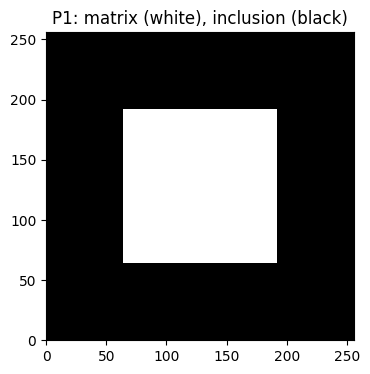

In [5]:
plt.figure(figsize=(4, 4))
plt.pcolormesh(phase[0].T, cmap='gray_r', vmin=0, vmax=1)
plt.gca().set_aspect('equal'); plt.title('P1: matrix (white), inclusion (black)')
plt.show()

## Loading & System Setup
Macroscopic gradient $\overline{\boldsymbol{\varepsilon}}=[1, 0]^\top$, so the effective energy coincides with the $A^\mathrm{eff}_{11}$ component of the effective conductivity tensor.

In [6]:
macro_grad = np.array([1.0, 0.0])
macro_grad_qxy = np.zeros(grad_shape) + macro_grad[None, :, None, None, None]

# RHS: divergence of the flux from the macroscopic gradient
rhs = -Bw_t(dot21(mat_data, macro_grad_qxy)).reshape(-1)

# System matrix
def K_fun(x):
    return Bw_t(dot21(mat_data, B(x.reshape(disp_shape)))).reshape(-1)

# Effective energy: (macro_grad + grad u) . A (macro_grad + grad u), averaged over the cell
def energy(x):
    grad = macro_grad_qxy + B(x.reshape(disp_shape))
    flux = dot21(mat_data, grad)
    return np.einsum('ijqxy,ijqxy,q->', grad, flux, quad_weights)

## Green's Preconditioner
Algorithm 2 from M. Ladecký, J. R. Leute, A. Falsafi, I. Pultarová, L. Pastewka, T. Junge, and J. Zeman. An optimal preconditioned FFT-accelerated finite element solver for homogenization. Applied Mathematics and Computation, 446:127835, 2023.

With the reference material $\mathbf{A}^\mathrm{ref}=\mathbf{I}$, the eigenvalues of the preconditioned matrix lie in $[\min(1,\kappa), \max(1,\kappa)]$.

In [7]:
K_ref = lambda x: Bw_t(dot21(I, B(x.reshape(disp_shape))))
G = np.zeros([dofs_per_node, dofs_per_node, *N])
for d in range(dofs_per_node):
    impulse = np.zeros(disp_shape)
    impulse[(d,) + (0,)*ndim] = 1
    G[d] = K_ref(impulse)
G = np.real(fft(G)).reshape(dofs_per_node, dofs_per_node, -1).transpose(2,0,1)
G[1:] = np.linalg.inv(G[1:])
M = G.transpose(1,2,0).reshape(dofs_per_node, dofs_per_node, *N)
Green_fun = lambda x: np.real(ifft(M * fft(x.reshape(disp_shape)))).reshape(-1)

# Spectral bounds of Green_fun K_fun
lam_min, lam_max = min(1, kappa), max(1, kappa)

## Solve
First the reference solution $\tilde{\boldsymbol{u}}_h$: PCG until the trivial upper bound $\|\mathbf{r}_k\|^2_{\mathbf{G}}/\lambda^\mathrm{L}_{\min}$ is below $10^{-20}$.
Then the monitored run from $\tilde{\boldsymbol{u}}_{h,0}=\mathbf{0}$ with the iterative error $e_k=\|\tilde{\boldsymbol{u}}_{h,k}-\tilde{\boldsymbol{u}}_h\|^2_{\mathbf{K}}$ and all bounds and estimates, until they are below $10^{-10}$.

In [8]:
u_h, _ = pcg(K_fun, rhs, Green_fun, lam_min, tol=1e-20, stop_on=("trivial",))
u_k, h = pcg(K_fun, rhs, Green_fun, lam_min, tau=0.25, tol=1e-10, u_ref=u_h)

k_star = np.argmax(h["error"] <= 1e-10)          # iterations of the run
print(f"PCG: {k_star} iterations to error <= 1e-10")
print(f"A_eff_h = {energy(u_h):.10f},   exact A_eff = {A_eff_exact:.10f}")
u_3, _ = pcg(K_fun, rhs, Green_fun, lam_min, maxiter=3, u_ref=u_h)
print(f"after 3 iterations: U_k - U_h = {energy(u_3) - energy(u_h):.10e},  ||u_k - u_h||_K^2 = {_['error'][-1]:.10e}")

PCG: 7 iterations to error <= 1e-10
A_eff_h = 0.5783285730,   exact A_eff = 0.5781193009
after 3 iterations: U_k - U_h = 4.2597372092e-05,  ||u_k - u_h||_K^2 = 4.2597372092e-05


## Repeated runs
The same steps as above for another contrast or grid, packed into one function.

In [9]:
def run(N_grid, kappa, tau=0.25, d_min=0, tol=1e-10):
    N = (N_grid, N_grid)
    pixel_size = (1 / N_grid, 1 / N_grid)
    B, Bw_t, quad_weights, nb_quad = get_gradient_operators(discretization_type, pixel_size, N, 1)
    grad_shape, disp_shape = (1, ndim, nb_quad) + N, (1,) + N

    x_c = (np.arange(N_grid) + 0.5) / N_grid
    inside = np.abs(x_c - 0.5) < 0.25
    phase = (1 - np.outer(inside, inside))[None, :, :].repeat(nb_quad, axis=0)
    mat_data = np.einsum('ij,qxy', I, phase) + np.einsum('ij,qxy', kappa * I, 1 - phase)

    macro_grad_qxy = np.zeros(grad_shape) + macro_grad[None, :, None, None, None]
    rhs = -Bw_t(dot21(mat_data, macro_grad_qxy)).reshape(-1)
    K_fun = lambda x: Bw_t(dot21(mat_data, B(x.reshape(disp_shape)))).reshape(-1)

    K_ref = lambda x: Bw_t(dot21(I, B(x.reshape(disp_shape))))
    impulse = np.zeros(disp_shape)
    impulse[0, 0, 0] = 1
    G = np.real(np.fft.fftn(K_ref(impulse), [*N])).reshape(1, 1, -1).transpose(2, 0, 1)
    G[1:] = np.linalg.inv(G[1:])
    M = G.transpose(1, 2, 0).reshape(1, 1, *N)
    Green_fun = lambda x: np.real(np.fft.ifftn(M * np.fft.fftn(x.reshape(disp_shape), [*N]))).reshape(-1)

    def energy(x):
        grad = macro_grad_qxy + B(x.reshape(disp_shape))
        return np.einsum('ijqxy,ijqxy,q->', grad, dot21(mat_data, grad), quad_weights)

    lam_min, lam_max = min(1, kappa), max(1, kappa)
    u_h, _ = pcg(K_fun, rhs, Green_fun, lam_min, tol=1e-20, stop_on=("trivial",))
    u_k, h = pcg(K_fun, rhs, Green_fun, lam_min, tau=tau, d_min=d_min, tol=tol, u_ref=u_h)
    h.update(lam_min=lam_min, lam_max=lam_max, A_h=energy(u_h),
             k_star=int(np.argmax(h["error"] <= 1e-10)))
    return h

## Plot 1: Iterative error, bounds and estimates (Section 6.1, Figure 2(a))
Left: $\kappa=10^{-3}$ as in Figure 2; right: the opposite contrast $\kappa=10^{3}$ (supplementary), a separate PCG run.
The PT lower bound and upper estimate refer to the delayed iterate $\ell=k-d$ and are drawn at $\ell$.

kappa = 1000: 8 iterations to e_k <= 1e-10


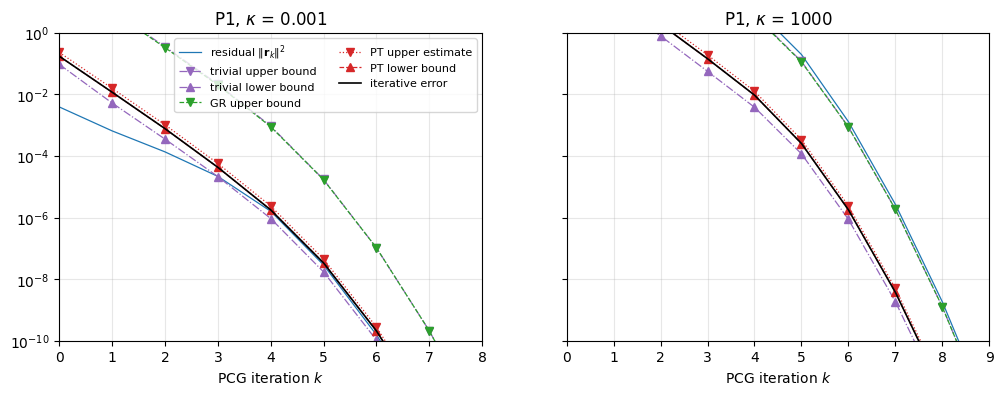

In [10]:
def plot_errors(h, lam_min, lam_max, title, ax):
    k = np.arange(len(h["error"]))
    l = np.array(sorted(h["LB"]))
    curves = [("rr", k, h["rr"][k], r'residual $\|\mathbf{r}_k\|^2$'),
              ("triv_UB", k, h["rz"][k] / lam_min, 'trivial upper bound'),
              ("triv_LB", k, h["rz"][k] / lam_max, 'trivial lower bound'),
              ("GR", k, h["GR"][k], 'GR upper bound'),
              ("PT_UE", l, [h["UE"][i] for i in l], 'PT upper estimate'),
              ("PT_LB", l, [h["LB"][i] for i in l], 'PT lower bound'),
              ("error", k, h["error"][k], 'iterative error')]
    for key, x, y, label in curves:
        ax.semilogy(x, np.abs(y), **STYLE[key], markevery=max(1, len(x) // 8), label=label)
    # as in Figure 2: y from 1e-10 to 1, x until the GR upper bound reaches 1e-10
    ax.set_xlim(0, last_iteration(h["GR"], 1e-10)); ax.set_ylim(1e-10, 1e0)
    ax.set_yticks(10.0 ** np.arange(-10, 1, 2)); ax.minorticks_off()
    ax.set_xlabel('PCG iteration $k$'); ax.set_title(title)
    ax.grid(alpha=0.3)

h_high = run(N_x, 1e3)                              # opposite contrast kappa = 1e3
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_errors(h, lam_min, lam_max, rf'P1, $\kappa$ = {kappa:g}', axes[0])
plot_errors(h_high, h_high["lam_min"], h_high["lam_max"], r'P1, $\kappa$ = 1000', axes[1])
print(f"kappa = 1000: {h_high['k_star']} iterations to e_k <= 1e-10")
axes[0].legend(fontsize=8, ncol=2); plt.show()

## Plot 2: Efficiency for increasing contrast (Section 6.1, Figure 3(a))
Efficiency = bound or estimate / iterative error it refers to.

kappa = 0.1: 6 iterations, GR efficiency at k = 0: 6, at the last iteration: 5.5
kappa = 0.01: 7 iterations, GR efficiency at k = 0: 55, at the last iteration: 50.5
kappa = 0.001: 7 iterations, GR efficiency at k = 0: 544, at the last iteration: 500.2


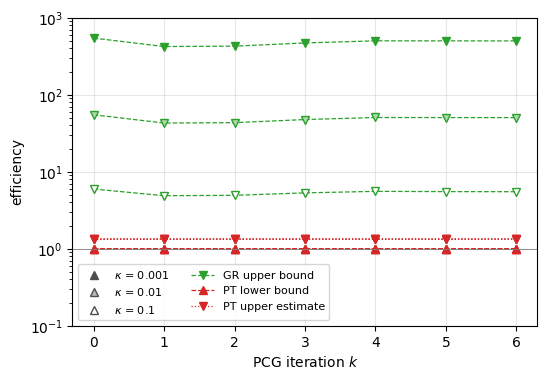

In [11]:
kappas = [1e-1, 1e-2, 1e-3]
runs = {kap: run(N_x, kap) for kap in kappas}

from matplotlib.colors import to_rgb
tint = {1e-3: 0.0, 1e-2: 0.6, 1e-1: 1.0, 1e3: 0.0, 1e2: 0.6, 1e1: 1.0}   # marker face: full colour, light tint, white
face = lambda colour, kap: tuple((1 - tint[kap]) * np.array(to_rgb(colour)) + tint[kap])

fig, ax = plt.subplots(figsize=(6, 4))
step = max(1, max(last_iteration(runs[kap]["error"], 1e-12) for kap in kappas) // 8)   # marker spacing
for kap in kappas:
    h = runs[kap]
    m = last_iteration(h["error"], 1e-12)             # as in Figure 3: until the error reaches 1e-12
    k = np.arange(m)
    l = np.array([i for i in sorted(h["LB"]) if i < m])
    for key, x, eff in [("GR", k, h["GR"][k] / h["error"][k]),
                        ("PT_UE", l, [h["UE"][i] / h["error"][i] for i in l]),
                        ("PT_LB", l, [h["LB"][i] / h["error"][i] for i in l])]:
        st = STYLE[key]
        ax.semilogy(x, eff, **st, markevery=step, mfc=face(st['color'], kap), mec=st['color'])
    print(f"kappa = {kap:g}: {h['k_star']} iterations, GR efficiency at k = 0: "
          f"{h['GR'][0] / h['error'][0]:.0f}, at the last iteration: {h['GR'][h['k_star']] / h['error'][h['k_star']]:.1f}")
ax.axhline(1, c='0.5', lw=0.6)
for kap in reversed(kappas):
    ax.plot([], [], c='0.3', ls='none', marker='^', mfc=face('0.3', kap), mec='0.3', label=rf'$\kappa$ = {kap:g}')
for key, label in [("GR", 'GR upper bound'), ("PT_LB", 'PT lower bound'), ("PT_UE", 'PT upper estimate')]:
    ax.plot([], [], **STYLE[key], label=label)
ax.set_ylim(1e-1, 1e3); ax.set_xlabel('PCG iteration $k$'); ax.set_ylabel('efficiency'); ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3); plt.show()

## Plot 2b: Efficiency for highly conducting inclusions (Section 6.1, supplementary to Figure 3)
The same as Plot 2 for $\kappa=10^{1},10^{2},10^{3}$, each a separate PCG run.

kappa = 10: 7 iterations, spectral bounds [1, 10], GR efficiency at k = 0: 4, at the last iteration: 5.5, PT lower bound efficiency min 1.00
kappa = 100: 8 iterations, spectral bounds [1, 100], GR efficiency at k = 0: 38, at the last iteration: 50.4, PT lower bound efficiency min 1.00
kappa = 1000: 8 iterations, spectral bounds [1, 1000], GR efficiency at k = 0: 376, at the last iteration: 499.0, PT lower bound efficiency min 1.00


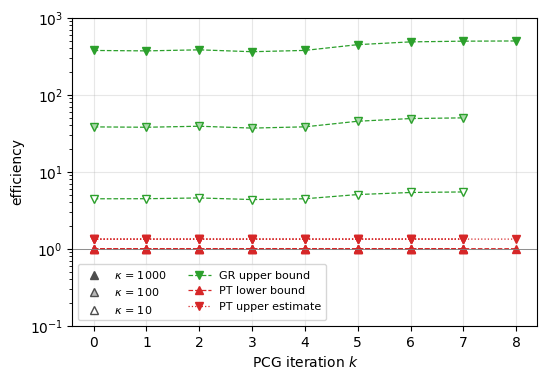

In [12]:
kappas_high = [1e1, 1e2, 1e3]
for kap in kappas_high:
    runs[kap] = h_high if kap == 1e3 else run(N_x, kap)       # kappa = 1e3: the run of Plot 1

fig, ax = plt.subplots(figsize=(6, 4))
step = max(1, max(last_iteration(runs[kap]["error"], 1e-12) for kap in kappas_high) // 8)   # marker spacing
for kap in kappas_high:
    h = runs[kap]
    m = last_iteration(h["error"], 1e-12)             # until the error reaches 1e-12, as in Figure 3
    k = np.arange(m)
    l = np.array([i for i in sorted(h["LB"]) if i < m])
    for key, x, eff in [("GR", k, h["GR"][k] / h["error"][k]),
                        ("PT_UE", l, [h["UE"][i] / h["error"][i] for i in l]),
                        ("PT_LB", l, [h["LB"][i] / h["error"][i] for i in l])]:
        st = STYLE[key]
        ax.semilogy(x, eff, **st, markevery=step, mfc=face(st['color'], kap), mec=st['color'])
    LB_eff = np.array([h["LB"][i] / h["error"][i] for i in l])
    print(f"kappa = {kap:g}: {h['k_star']} iterations, spectral bounds [{h['lam_min']:g}, {h['lam_max']:g}], "
          f"GR efficiency at k = 0: {h['GR'][0] / h['error'][0]:.0f}, at the last iteration: "
          f"{h['GR'][h['k_star']] / h['error'][h['k_star']]:.1f}, PT lower bound efficiency min {LB_eff.min():.2f}")
ax.axhline(1, c='0.5', lw=0.6)
for kap in reversed(kappas_high):
    ax.plot([], [], c='0.3', ls='none', marker='^', mfc=face('0.3', kap), mec='0.3', label=rf'$\kappa$ = {kap:g}')
for key, label in [("GR", 'GR upper bound'), ("PT_LB", 'PT lower bound'), ("PT_UE", 'PT upper estimate')]:
    ax.plot([], [], **STYLE[key], label=label)
ax.set_ylim(1e-1, 1e3); ax.set_xlabel('PCG iteration $k$'); ax.set_ylabel('efficiency'); ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3); plt.show()

## Plot 3: Fixed and adaptive delay (Section 6.2; the paper shows P2 and P3 in Figure 4, P1 in the text)
With a fixed delay $d$, the lower bound $e_\ell \geq \Delta_\ell+\dots+\Delta_{\ell+d-1} = U_\ell - U_{\ell+d}$, with $U_k=\overline{\boldsymbol{\varepsilon}}^\top\mathbf{A}^\mathrm{eff}_{h,k}\overline{\boldsymbol{\varepsilon}}$.
The fixed-delay bounds are sums of the $\Delta_j$ of the run with $\kappa=10^{-3}$. The adaptive delay is the PT lower bound of that run ($\tau=0.25$); the adaptive delay with the minimal delay $d_\min=10$ is a separate PCG run with `d_min=10`.

fixed d =  1: minimal efficiency 0.9321
fixed d =  2: minimal efficiency 0.9955
fixed d =  5: minimal efficiency 1.0000
fixed d = 10: minimal efficiency 1.0000
adaptive            : minimal efficiency 0.9998, delays 3-3
adaptive, $d \geq 10$: minimal efficiency 1.0000, delays 10-10


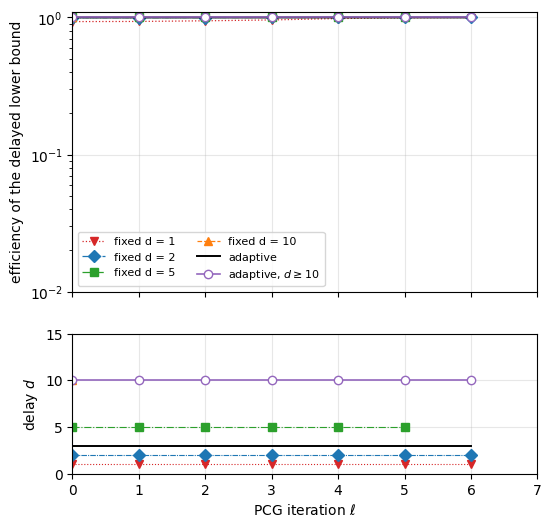

In [13]:
h = runs[1e-3]
Delta, err = h["Delta"], h["error"]
last = last_iteration(err, 1e-12)                     # as in Figure 4: x-axis until the error reaches 1e-12

runs_delay = {0: h, 10: run(N_x, 1e-3, d_min=10)}      # PCG runs with the adaptive delay, without and with d_min = 10

def adaptive(h):
    l = np.array([i for i in sorted(h["LB"]) if i < last])
    return l, np.array([h["LB"][i] for i in l]), np.array([h["LB_at"][i] - i for i in l])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, height_ratios=[2, 1])
fixed_styles = {1: ('tab:red', ':', 'v'), 2: ('tab:blue', (0, (5, 1, 1, 1)), 'D'),
                5: ('tab:green', '-.', 's'), 10: ('tab:orange', '--', '^')}
for d, (c, ls, m) in fixed_styles.items():
    l = np.arange(min(last, len(err) - d))
    LB_d = np.array([Delta[i:i + d].sum() for i in l])
    ax1.semilogy(l, LB_d / err[l], c=c, ls=ls, marker=m, lw=0.9, markevery=max(1, last // 10), label=f'fixed d = {d}')
    ax2.plot(l, d + 0 * l, c=c, ls=ls, marker=m, lw=0.8, markevery=max(1, last // 10))
    print(f"fixed d = {d:2d}: minimal efficiency {np.min(LB_d / err[l]):.4f}")
for d_min, st, name in [(0, dict(c='black', lw=1.4), 'adaptive'),
                        (10, dict(c='tab:purple', lw=1.2, marker='o', mfc='white', markevery=max(1, last // 10)), r'adaptive, $d \geq 10$')]:
    l, LB, delay = adaptive(runs_delay[d_min])
    ax1.semilogy(l, LB / runs_delay[d_min]["error"][l], **st, label=name)
    ax2.plot(l, delay, **st)
    print(f"{name:20s}: minimal efficiency {np.min(LB / runs_delay[d_min]['error'][l]):.4f}, delays {delay.min()}-{delay.max()}")
ax1.set_ylim(1e-2, 1.1); ax2.set_ylim(0, 15); ax1.set_xlim(0, last)
ax1.set_ylabel('efficiency of the delayed lower bound'); ax1.legend(fontsize=8, ncol=2); ax1.grid(alpha=0.3)
ax2.set_ylabel('delay $d$'); ax2.set_xlabel(r'PCG iteration $\ell$'); ax2.grid(alpha=0.3)
plt.show()

## Additional experiment: tolerance $\tau$ of the adaptive delay (Section 6.2)
A smaller $\tau$ gives a larger delay and a sharper PT lower bound, which becomes available later; the PT upper estimate is $\mathrm{PT}^\mathrm{L}_\ell/(1-\tau)$.
Each setting is a separate PCG run with $\kappa=10^{-3}$: $\tau=0.5$, $0.25$ (the value of the paper), $0.1$ and $0.05$, and $\tau=0.25$ with the minimal delay $d_\min=10$. Each run stops when its own PT upper estimate, GR upper bound, trivial upper bound and residual are below $10^{-10}$.

$\tau$ = 0.5                : PT lower bound efficiency min 1.000, median 1.000;  PT upper estimate efficiency 2.000-2.000;  mean delay 3.0;  10 PCG iterations
$\tau$ = 0.25               : PT lower bound efficiency min 1.000, median 1.000;  PT upper estimate efficiency 1.333-1.333;  mean delay 3.0;  10 PCG iterations
$\tau$ = 0.1                : PT lower bound efficiency min 1.000, median 1.000;  PT upper estimate efficiency 1.111-1.111;  mean delay 3.0;  10 PCG iterations
$\tau$ = 0.05               : PT lower bound efficiency min 1.000, median 1.000;  PT upper estimate efficiency 1.052-1.053;  mean delay 3.0;  10 PCG iterations
$\tau$ = 0.25, $d \geq 10$  : PT lower bound efficiency min 1.000, median 1.000;  PT upper estimate efficiency 1.333-1.333;  mean delay 10.0;  17 PCG iterations


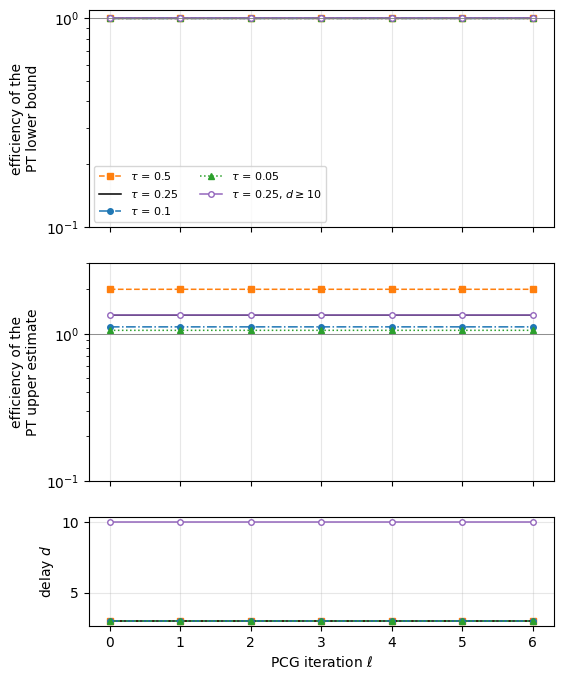

In [14]:
taus = {0.5: ('tab:orange', '--', 's'), 0.25: ('black', '-', None), 0.1: ('tab:blue', '-.', 'o'), 0.05: ('tab:green', ':', '^')}
variants = [(rf'$\tau$ = {tau:g}', tau, 0, dict(c=c, ls=ls, marker=m)) for tau, (c, ls, m) in taus.items()]
variants.append((r'$\tau$ = 0.25, $d \geq 10$', 0.25, 10, dict(c='tab:purple', ls='-', marker='o', mfc='white')))

runs_tau = {label: run(N_x, 1e-3, tau=tau, d_min=d_min) for label, tau, d_min, _ in variants}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 8), sharex=True, height_ratios=[2, 2, 1])
for label, tau, d_min, st in variants:
    h = runs_tau[label]
    err = h["error"]
    last = last_iteration(err, 1e-12)
    l = np.array([i for i in sorted(h["LB"]) if i < last and err[i] > 0])
    delay = np.array([h["LB_at"][i] - i for i in l])
    eff_L = np.array([h["LB"][i] for i in l]) / err[l]          # PT lower bound of this run
    eff_U = np.array([h["UE"][i] for i in l]) / err[l]          # PT upper estimate of this run
    kw = dict(st, lw=1.1, markersize=4, markevery=max(1, len(l) // 8))
    ax1.semilogy(l, eff_L, label=label, **kw)
    ax2.semilogy(l, eff_U, **kw)
    ax3.plot(l, delay, **kw)
    print(f"{label:28s}: PT lower bound efficiency min {eff_L.min():.3f}, median {np.median(eff_L):.3f};  "
          f"PT upper estimate efficiency {eff_U.min():.3f}-{eff_U.max():.3f};  mean delay {delay.mean():.1f};  "
          f"{len(err) - 1} PCG iterations")
for ax in (ax1, ax2):
    ax.axhline(1, c='0.5', lw=0.6)
ax1.set_ylim(1e-1, 1.1); ax2.set_ylim(1e-1, 3)            # as in the paper's tau figure
ax1.set_ylabel('efficiency of the\nPT lower bound'); ax2.set_ylabel('efficiency of the\nPT upper estimate')
ax3.set_ylabel('delay $d$'); ax3.set_xlabel(r'PCG iteration $\ell$')
ax1.legend(fontsize=8, ncol=2)
for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.3)
plt.show()

## Plot 4: Stopping criteria (Section 6.3, Figure 5, problem P1)
Each criterion with the tolerance $\mathit{tol}_\mathrm{CG}=10^{-8}$ on the iterative error, against the ideal stop $k^\ast=\min\{k: e_k\leq\mathit{tol}_\mathrm{CG}\}$.
The PT upper estimate stops at the iteration $k$ at which an estimate below the tolerance becomes available.

kappa = 0.1: k* = 5, stops: {'residual': 5, 'trivial upper bound': 6, 'GR upper bound': 6, 'PT upper estimate': 8}
kappa = 0.01: k* = 6, stops: {'residual': 6, 'trivial upper bound': 6, 'GR upper bound': 6, 'PT upper estimate': 9}
kappa = 0.001: k* = 6, stops: {'residual': 6, 'trivial upper bound': 7, 'GR upper bound': 7, 'PT upper estimate': 9}
kappa = 10: k* = 6, stops: {'residual': 6, 'trivial upper bound': 6, 'GR upper bound': 6, 'PT upper estimate': 9}
kappa = 100: k* = 7, stops: {'residual': 8, 'trivial upper bound': 8, 'GR upper bound': 8, 'PT upper estimate': 10}
kappa = 1000: k* = 7, stops: {'residual': 8, 'trivial upper bound': 8, 'GR upper bound': 8, 'PT upper estimate': 10}


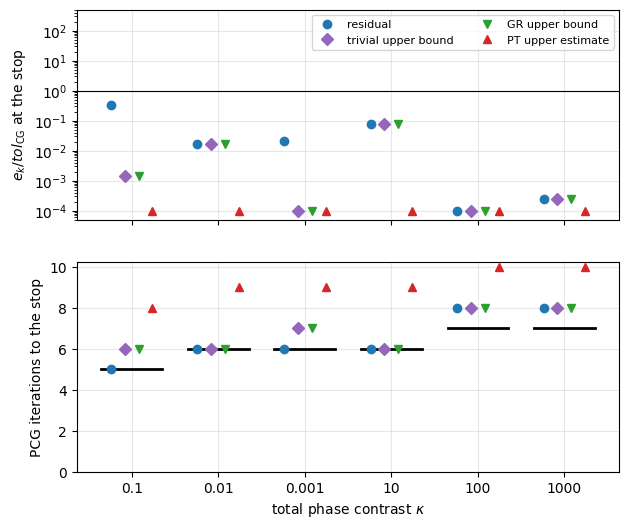

In [15]:
tol_stop = 1e-8
contrasts = [1e-1, 1e-2, 1e-3, 1e1, 1e2, 1e3]
for kap in contrasts:
    if kap not in runs:
        runs[kap] = run(N_x, kap)

def stop_iterations(h):
    n = len(h["error"])
    latest_UE = np.full(n, np.inf)                 # latest available upper estimate at k
    for l in sorted(h["UE"]):
        latest_UE[h["LB_at"][l]:] = h["UE"][l]
    criteria = {"residual": h["rr"], "trivial upper bound": h["rz"] / h["lam_min"],
                "GR upper bound": h["GR"], "PT upper estimate": latest_UE}
    first = lambda q: int(np.argmax(q <= tol_stop)) if np.any(q <= tol_stop) else None
    return first(h["error"]), {name: first(q) for name, q in criteria.items()}

# markers of Figure 5: here they identify the criterion, not the direction of the bound
styles = {"residual": ('o', 'tab:blue'), "trivial upper bound": ('D', 'tab:purple'),
          "GR upper bound": ('v', 'tab:green'), "PT upper estimate": ('^', 'tab:red')}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
for i, kap in enumerate(contrasts):
    k_ideal, stops = stop_iterations(runs[kap])
    ax2.plot([i - 0.35, i + 0.35], [k_ideal, k_ideal], 'k-', lw=2)
    for j, (name, k) in enumerate(stops.items()):
        if k is None:
            continue
        x = i - 0.24 + 0.16 * j
        m, c = styles[name]
        ax1.semilogy(x, max(runs[kap]["error"][k] / tol_stop, 1e-4), marker=m, c=c, ls='',
                     label=name if i == 0 else None)
        ax2.plot(x, k, marker=m, c=c, ls='')
    print(f"kappa = {kap:g}: k* = {k_ideal}, stops: {stops}")
ax1.axhline(1, c='k', lw=0.8); ax1.set_ylabel(r'$e_k/\mathit{tol}_\mathrm{CG}$ at the stop'); ax1.legend(fontsize=8, ncol=2)
ax1.set_ylim(1e-4 / 2, 5e2); ax2.set_ylim(0, None)          # as in Figure 5
ax2.set_ylabel('PCG iterations to the stop'); ax2.set_xticks(range(len(contrasts)), [f'{c:g}' for c in contrasts])
ax2.set_xlabel(r'total phase contrast $\kappa$'); ax1.grid(alpha=0.3); ax2.grid(alpha=0.3)
plt.show()

## Plot 5: Discretization and total error (Section 6.4, Figure 6(a))
Total error $e_{h,k}$ = iterative error $e_k$ + discretization error $e_h$, with $e_{h,k}=\overline{\boldsymbol{\varepsilon}}^\top(\mathbf{A}^\mathrm{eff}_{h,k}-\mathbf{A}^\mathrm{eff})\overline{\boldsymbol{\varepsilon}}$ and the exact $\mathbf{A}^\mathrm{eff}$ of Obnosov.

N =  256: discretization error 2.09e-04, iterative error below it from k = 3
N =  512: discretization error 8.30e-05, iterative error below it from k = 3
N = 1024: discretization error 3.29e-05, iterative error below it from k = 4


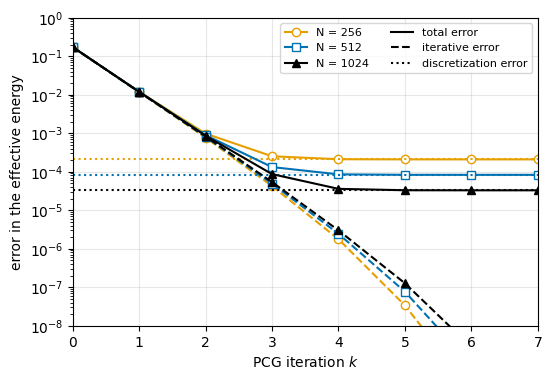

In [16]:
grids = {256: ('#E69F00', 'o', 'white'), 512: ('#0072B2', 's', 'white'), 1024: ('black', '^', 'black')}
fig, ax = plt.subplots(figsize=(6, 4))
xmax, ytop = 0, 0
for N_grid, (c, m, fill) in grids.items():
    h = runs[1e-3] if N_grid == N_x else run(N_grid, 1e-3)
    k = np.arange(h["k_star"] + 1)
    e_h = h["A_h"] - A_eff_exact
    mk = dict(c=c, marker=m, mfc=fill, markevery=max(1, h["k_star"] // 6))
    ax.semilogy(k, h["error"][k] + e_h, ls='-', label=f'N = {N_grid}', **mk)
    ax.semilogy(k, h["error"][k], ls='--', **mk)
    ax.axhline(e_h, c=c, ls=':')
    xmax = max(xmax, h["k_star"])
    ytop = max(ytop, 10.0 ** np.ceil(np.log10(np.max(h["error"][k] + e_h))))
    print(f"N = {N_grid:4d}: discretization error {e_h:.2e}, "
          f"iterative error below it from k = {np.argmax(h['error'] <= e_h)}")
ax.plot([], [], 'k-', label='total error'); ax.plot([], [], 'k--', label='iterative error')
ax.plot([], [], 'k:', label='discretization error')
ax.set_xlim(0, xmax); ax.set_ylim(1e-8, ytop)         # as in Figure 6
ax.set_xlabel('PCG iteration $k$'); ax.set_ylabel('error in the effective energy')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3); plt.show()